# TracIn - MNIST Self-Influence & Proponents/Opponents

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(42)

Using device: cuda


## Load the data

### Evaluation Approach: MNIST
**Reference: Paper Section 4.1 & 4.3**

We evaluate `TracIn` on a digit classification task using MNIST. To simulate real-world mislabelling errors, we first train a model on correct data. Then, for 10% of the training data, we randomly flip the label to an incorrect one.
Incorrectly labelled examples are likely to be strong proponents for themselves. Therefore, when we sort training examples by decreasing self-influence, `TracIn` tends to rank mislabelled examples at the beginning of the ranking.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=512, shuffle=True, num_workers=2, pin_memory=True
)

# Flip 10% of training labels
num_flip = int(0.1 * len(train_dataset))
flip_idx = np.random.choice(len(train_dataset), num_flip, replace=False)
for i in flip_idx:
    train_dataset.targets[i] = np.random.randint(0, 10)


## Build Simple feed forward Neural Network training with checkpoints

In [3]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(-1, 784)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [4]:
# Training with GPU + Checkpointing
model = SimpleNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

checkpoints = []
checkpoint_epochs = [5, 10, 20, 30]

for epoch in range(30):
    model.train()
    for data, target in tqdm(train_loader, desc=f'Epoch {epoch+1}/30'):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    
    if epoch + 1 in checkpoint_epochs:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},  # save on CPU
            'learning_rate': 0.01
        }
        checkpoints.append(checkpoint)
        torch.save(model.state_dict(), f'checkpoint_epoch_{epoch+1}.pt')
        print(f'Saved checkpoint at epoch {epoch+1}')

Epoch 5/30: 100%|██████████| 118/118 [00:06<00:00, 19.23it/s]


Saved checkpoint at epoch 5


Epoch 10/30: 100%|██████████| 118/118 [00:06<00:00, 18.83it/s]


Saved checkpoint at epoch 10


Epoch 20/30: 100%|██████████| 118/118 [00:06<00:00, 19.31it/s]


Saved checkpoint at epoch 20


Epoch 30/30: 100%|██████████| 118/118 [00:06<00:00, 19.10it/s]

Saved checkpoint at epoch 30


## Main Implementation of TraceIn

### Understanding TracIn: Tracing Gradient Descent

TracIn is a method introduced to estimate the influence of a specific training example on a model's prediction for a test example. The core idea is to trace how the loss on a test point changes during the training process whenever the training example of interest was utilized. This allows for identifying which training points are helpful (proponents) or harmful (opponents) for a given prediction.

#### The Core Idea

Inspired by the fundamental theorem of calculus, TracIn decomposes the total change in a test example's loss over the entire training process into contributions from each training example. It effectively "traces" the influence along the path taken by gradient descent.

#### Methodology

The method is developed from an idealized concept to a practical, scalable implementation:

1. **Idealized Influence (`TracIn_Ideal`)**
   The idealized influence of a training example $z$ on a test example $z'$ is defined as the total reduction in the loss on the test example $z'$ that is induced by the training process whenever the training example $z$ is utilized.
   $$TracInIdeal(z, z') = \sum_{t: z_t=z} \ell(w_t, z') - \ell(w_{t+1}, z')$$

2. **First-Order Approximation (`TracIn`)**
   To make the method practical, the change in loss is approximated using a first-order Taylor expansion. The change in loss at a single step $t$ is approximately the dot product of the test loss gradient and the parameter update vector.
   $$TracIn(z, z') = \sum_{t: z_t=z} \eta_t \nabla\ell(w_t, z') \cdot \nabla\ell(w_t, z)$$

3. **Practical Heuristic via Checkpoints (`TracInCP`)**
   Storing parameters and gradients at every step is impractical. The most practical version, `TracInCP`, uses model checkpoints saved at regular intervals during training. It approximates the influence by calculating the gradient dot products only at these checkpoint states.
   $$TracInCP(z, z') = \sum_{i=1}^k \eta_i \nabla\ell(w_{t_i}, z) \cdot \nabla\ell(w_{t_i}, z')$$

#### Proponents and Opponents

* **Proponents**: Training examples that have a *positive* value of influence score, because they serve to reduce loss.
* **Opponents**: Training examples that have a *negative* value of influence score, because they increase loss.

#### Applications and Advantages

TracIn has been successfully applied to tasks like identifying mislabeled data. Compared to other methods like Influence Functions and the Representer Point method, TracIn is **simple** to implement (requiring only gradients, checkpoints, and loss functions), **general** (applicable to any model trained with SGD variants), and **versatile**.


In [5]:
def compute_last_layer_gradient(model, example, label, criterion, device):
    model.zero_grad()
    example = example.unsqueeze(0).to(device)
    label = label.to(device)
    output = model(example)
    loss = criterion(output, label)
    loss.backward()
    
    # Last layer gradient only (fc4.weight)
    grad_weight = model.fc4.weight.grad.view(-1)
    grad_bias = model.fc4.bias.grad.view(-1)
    grad = torch.cat([grad_weight, grad_bias])
    return grad

In [6]:
def load_checkpoint_models(checkpoints, device):
    loaded = []
    for ckpt in checkpoints:
        model = SimpleNN().to(device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        loaded.append((model, ckpt['learning_rate']))
    return loaded
def precompute_test_gradients(test_example, test_label, loaded_models, criterion, device):
    test_grads = []
    for model, lr in loaded_models:
        g = compute_last_layer_gradient(model, test_example, test_label, criterion, device)
        test_grads.append(g)
    return test_grads

In [7]:
def compute_tracin_score(train_example, train_label, loaded_models, test_grads, criterion, device):
    total_influence = 0.0

    for (model, lr), test_grad in zip(loaded_models, test_grads):
        train_grad = compute_last_layer_gradient(model, train_example, train_label, criterion, device)
        total_influence += lr * torch.dot(train_grad, test_grad).item()

    return total_influence

In [8]:
def compute_all_self_influences(train_dataset, checkpoints, criterion, device, max_examples=10000):
    loaded_models = load_checkpoint_models(checkpoints, device)
    self_influences = []
    
    for idx in tqdm(range(min(max_examples, len(train_dataset))), desc="Computing self-influences"):
        example, label_int = train_dataset[idx]
        label = torch.tensor([label_int], device=device)
        
        score = 0.0
        for model, lr in loaded_models:
            grad = compute_last_layer_gradient(model, example, label, criterion, device)
            score += lr * torch.sum(grad ** 2).item()
        
        self_influences.append(score)
    
    return np.array(self_influences), list(range(min(max_examples, len(train_dataset))))

In [9]:
# Compute self-influences (using last-layer + GPU)
self_influences, indices = compute_all_self_influences(
    train_dataset, checkpoints, criterion, device, max_examples=10000
)

sorted_idx = np.argsort(self_influences)[::-1]

print("Top 10 high self-influence examples:")
for i in range(10):
    idx = sorted_idx[i]
    print(f"Example {idx}: influence={self_influences[idx]:.4f}, label={train_dataset[idx][1]}")

Computing self-influences: 100%|██████████| 10000/10000 [00:51<00:00, 195.76it/s]

Top 10 high self-influence examples:
Example 8508: influence=5.7182, label=1
Example 6049: influence=5.6240, label=2
Example 2415: influence=5.4376, label=5
Example 821: influence=5.4127, label=7
Example 8477: influence=5.4082, label=7
Example 2422: influence=5.3660, label=7
Example 8331: influence=5.3430, label=0
Example 4664: influence=5.3285, label=9
Example 6028: influence=5.3167, label=3
Example 5271: influence=5.1997, label=0


In [10]:
def find_proponents_opponents(test_example, test_label, train_dataset,
                              loaded_models, criterion, device, top_k=5):
    test_grads = precompute_test_gradients(test_example, test_label, loaded_models, criterion, device)

    scores = []
    for idx in tqdm(range(len(train_dataset)), desc="Computing influences"):
        train_ex, train_label_int = train_dataset[idx]
        train_label = torch.tensor([train_label_int], device=device)

        score = compute_tracin_score(
            train_ex, train_label, loaded_models, test_grads, criterion, device
        )
        scores.append((score, idx))

    scores.sort(reverse=True)
    return scores[:top_k], scores[-top_k:]

In [11]:
# Example usage: Pick a test example
test_idx = 0
test_example, test_label_int = test_dataset[test_idx]
test_label = torch.tensor([test_label_int])

# Load the checkpoint models into a list of (model, lr) tuples
loaded_models = load_checkpoint_models(checkpoints, device)

# Now pass loaded_models instead of checkpoints
proponents, opponents = find_proponents_opponents(
    test_example, test_label, train_dataset, loaded_models, criterion, device, top_k=5
)
print("Proponents (helpful):", [idx for _, idx in proponents])
print("Opponents (harmful):", [idx for _, idx in opponents])

Computing influences: 100%|██████████| 60000/60000 [05:01<00:00, 199.21it/s]


Proponents (helpful): [59777, 28528, 14786, 53722, 37622]
Opponents (harmful): [3255, 48759, 10487, 14284, 48165]


In [12]:
def visualize_influences(test_example, test_label_int, proponents, opponents, train_dataset, model=None, device=None):
    """
    Visualize test example with its proponents and opponents in a clean layout.
    Layout:
        Row 0: Test example (col 0) | Proponent images (col 1-5)
        Row 1: Empty             | Opponent images (col 1-5)
    
    Actually we'll do a 3-row layout:
        Row 0: Test example centered, with label info
        Row 1: 5 Proponents
        Row 2: 5 Opponents
    """
    
    # Get model prediction if model provided
    pred_label = None
    if model is not None and device is not None:
        model.eval()
        with torch.no_grad():
            out = model(test_example.unsqueeze(0).to(device))
            pred_label = out.argmax(dim=1).item()
    
    fig = plt.figure(figsize=(18, 10))
    fig.patch.set_facecolor('white')
    
    true_lbl = test_label_int
    title = f'Test Example  |  True Label: {true_lbl}'
    if pred_label is not None:
        correct = '✓ Correctly Classified' if pred_label == true_lbl else '✗ Incorrectly Classified'
        title += f'  |  Predicted: {pred_label}  ({correct})'
    fig.suptitle(title, fontsize=15, fontweight='bold', y=0.98)
    
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(
        3, 6,
        figure=fig,
        hspace=0.55,
        wspace=0.15,
        left=0.04, right=0.98,
        top=0.88, bottom=0.04
    )
    
    def to_display(tensor):
        img = tensor.squeeze().numpy()
        img = img * 0.3081 + 0.1307          # undo Normalize
        img = np.clip(img, 0, 1)
        return img
    ax_test = fig.add_subplot(gs[:, 0])
    ax_test.imshow(to_display(test_example), cmap='gray', interpolation='nearest')
    ax_test.set_title(
        f'Test Image\nLabel: {true_lbl}' + (f'\nPred: {pred_label}' if pred_label is not None else ''),
        fontsize=11, color='steelblue', fontweight='bold', pad=6
    )
    ax_test.axis('off')
    for spine in ax_test.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('steelblue')
        spine.set_linewidth(2.5)
    
    ax_prop_hdr = fig.add_subplot(gs[0, 1:4])
    ax_prop_hdr.axis('off')
    ax_prop_hdr.text(
        0.5, 0.3, 'Proponents  (Helpful)',
        ha='center', va='center', fontsize=13,
        color='green', fontweight='bold',
        transform=ax_prop_hdr.transAxes
    )
    
    ax_opp_hdr = fig.add_subplot(gs[0, 4:])
    ax_opp_hdr.axis('off')
    ax_opp_hdr.text(
        0.5, 0.3, 'Opponents  (Harmful)',
        ha='center', va='center', fontsize=13,
        color='crimson', fontweight='bold',
        transform=ax_opp_hdr.transAxes
    )
    
    for i, (score, idx) in enumerate(proponents):
        img, lbl = train_dataset[idx]
        ax = fig.add_subplot(gs[1, i + 1])
        ax.imshow(to_display(img), cmap='gray', interpolation='nearest')
        ax.set_title(
            f'Score: {score:+.4f}\nLabel: {lbl}',
            fontsize=8.5, color='darkgreen', pad=4
        )
        ax.axis('off')
        # Green border
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('green')
            spine.set_linewidth(1.8)
    

    for i, (score, idx) in enumerate(opponents):
        img, lbl = train_dataset[idx]
        ax = fig.add_subplot(gs[2, i + 1])
        ax.imshow(to_display(img), cmap='gray', interpolation='nearest')
        ax.set_title(
            f'Score: {score:+.4f}\nLabel: {lbl}',
            fontsize=8.5, color='crimson', pad=4
        )
        ax.axis('off')
        # Red border
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('crimson')
            spine.set_linewidth(1.8)
    
    plt.savefig('tracin_visualization.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("Saved → tracin_visualization.png")

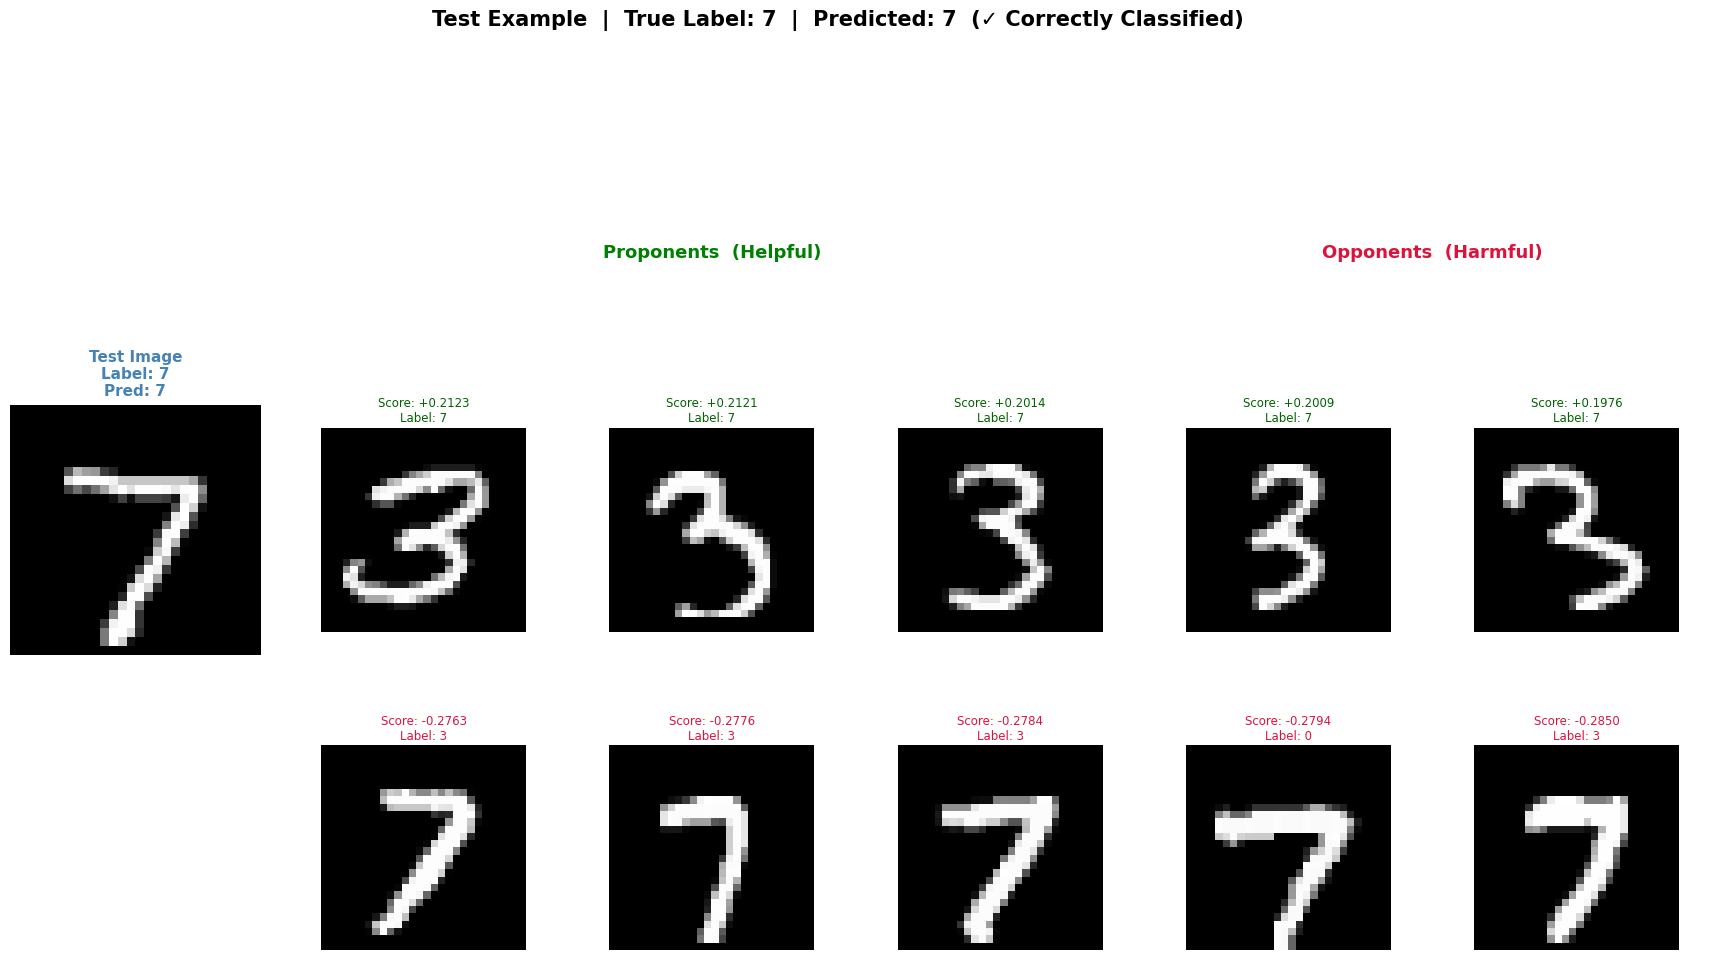

Saved → tracin_visualization.png


In [13]:
# Load the final checkpoint model for prediction
final_model = SimpleNN().to(device)
final_model.load_state_dict(checkpoints[-1]['model_state_dict'])
final_model.eval()

visualize_influences(
    test_example,
    test_label_int,
    proponents,
    opponents,
    train_dataset,
    model=final_model,
    device=device
)

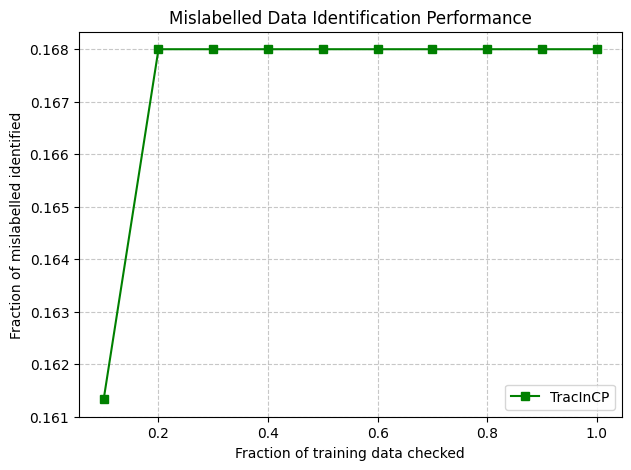

In [14]:
# Convert to set for O(1) lookup time
mislabelled_set = set(flip_idx)
total_mislabelled = len(mislabelled_set)

# Define the fractions of the dataset to check (e.g., 10% to 100%)
fractions_to_check = np.arange(0.1, 1.1, 0.1) 
fraction_identified = []

for frac in fractions_to_check:
    # 1. Calculate how many examples represent this fraction
    k = int(frac * len(train_dataset))
    
    # 2. Get the top k indices with highest self-influence
    top_k_indices = sorted_idx[:k]
    
    # 3. Count how many of these top k are actually mislabelled
    found_mislabelled = sum(1 for idx in top_k_indices if idx in mislabelled_set)
    
    # 4. Calculate the fraction of total mislabelled examples found
    fraction_identified.append(found_mislabelled / total_mislabelled)

# Plotting the metric
plt.figure(figsize=(7, 5))
plt.plot(fractions_to_check, fraction_identified, marker='s', color='green', label='TracInCP')
plt.xlabel('Fraction of training data checked')
plt.ylabel('Fraction of mislabelled identified')
plt.title('Mislabelled Data Identification Performance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


--- Retraining with top 0.0% labels fixed ---
Corrected 0 actual mislabelled examples.
Test Accuracy: 97.20%

--- Retraining with top 10.0% labels fixed ---
Corrected 968 actual mislabelled examples.
Test Accuracy: 97.22%

--- Retraining with top 20.0% labels fixed ---
Corrected 1008 actual mislabelled examples.
Test Accuracy: 97.44%

--- Retraining with top 30.0% labels fixed ---
Corrected 1008 actual mislabelled examples.
Test Accuracy: 97.41%

--- Retraining with top 40.0% labels fixed ---
Corrected 1008 actual mislabelled examples.
Test Accuracy: 97.35%

--- Retraining with top 50.0% labels fixed ---
Corrected 1008 actual mislabelled examples.
Test Accuracy: 97.35%


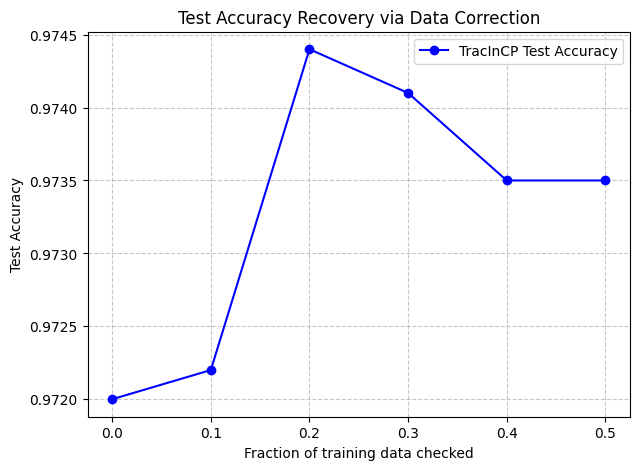

In [17]:
import copy
original_targets = copy.deepcopy(train_dataset.targets)


import torch.optim as optim
import torch.nn.functional as F

test_accuracies = []
fractions_to_fix = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5] 

# Ensure test_loader is available for evaluation
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)

for frac in fractions_to_fix:
    print(f"\n--- Retraining with top {frac*100}% labels fixed ---")
    
    # 1. Create a fresh copy of the mislabelled dataset
    fixed_dataset = copy.deepcopy(train_dataset)
    
    # 2. Identify the top K anomalies using self-influence scores
    k = int(frac * len(train_dataset))
    top_k_indices = sorted_idx[:k]
    
    # 3. Fix the labels for only the correctly identified mislabelled points
    fixed_count = 0
    for idx in top_k_indices:
        if idx in mislabelled_set:
            fixed_dataset.targets[idx] = original_targets[idx]
            fixed_count += 1
            
    print(f"Corrected {fixed_count} actual mislabelled examples.")
            
    # 4. Create a new DataLoader with the partially fixed dataset
    fixed_loader = torch.utils.data.DataLoader(
        fixed_dataset, batch_size=512, shuffle=True, num_workers=2, pin_memory=True
    )
    
    # 5. Initialize a NEW model from scratch to prevent weight contamination
    retrain_model = SimpleNN().to(device)
    retrain_optimizer = torch.optim.SGD(retrain_model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    # 6. Retrain Loop 
    retrain_epochs = 15 # Epochs can be adjusted based on compute constraints
    retrain_model.train()
    
    for epoch in range(retrain_epochs):
        for data, target in fixed_loader:
            data, target = data.to(device), target.to(device)
            retrain_optimizer.zero_grad()
            output = retrain_model(data)
            loss = criterion(output, target)
            loss.backward()
            retrain_optimizer.step()
            
    # 7. Evaluate on the pristine test dataset
    retrain_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = retrain_model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    test_accuracies.append(accuracy)


plt.figure(figsize=(7, 5))
plt.plot(fractions_to_fix, test_accuracies, marker='o', color='blue', label='TracInCP Test Accuracy')

plt.xlabel('Fraction of training data checked')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Recovery via Data Correction')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()